In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
propellant_age = np.array([15.5, 23.75, 8, 17, 5.5, 19, 24, 2.5, 7.5, 11])
storage_temp = np.array([40, 23.25, 17, 21, 10, 12, 20, 12, 15, 26])
pass_fail = np.array([0, 0, 1, 0, 1, 1, 0, 1, 1, 0], dtype=np.int8)  #(1 = pass, 0 = fail)

In [3]:
y_in = pass_fail
y1_in = 1 - y_in
nx = propellant_age.size

In [5]:
def objective_function(w):
    z = w[0] + w[1] * propellant_age + w[2] * storage_temp
    z1 = np.log(1 + np.exp(-z))
    z2 = np.log(1 + np.exp(z))
    return np.dot(y_in, z1) + np.dot(y1_in, z2)

In [6]:
def gradient_function(w):
    hi = 1 / (1 + np.exp(-w[0] - w[1] * propellant_age - w[2] * storage_temp))
    yh = 1. * hi - 1. * y_in
    return np.array([np.sum(yh), np.dot(yh, propellant_age), np.dot(yh, storage_temp)])


In [7]:
def line_search(objective_function, gradient, x):
    beta = 0.1
    stepsize = 1
    trial = 100
    tau = 0.5
    for i in range(trial):
        fx1 = objective_function(x)
        fx2 = objective_function(x - stepsize * gradient)
        c = -beta * stepsize * np.dot(gradient, gradient)
        if fx2 - fx1 <= c:
            break
        else:
            stepsize = tau * stepsize
    return stepsize

In [8]:
maxit = 1000000
epsilon = 1.e-3
w = np.array([-2, 3, 0.5])


In [9]:
for i in range(maxit):
    gradient = gradient_function(w)
    b = np.linalg.norm(gradient)
    if b < epsilon:
        break
    stepsize = line_search(objective_function, gradient, w)
    w = w - stepsize * gradient
    if i % 1000 == 0:
        print(f"Iteration {i}: Gradient Norm = {b}")

C:\Users\garimamittal\AppData\Local\Temp\ipykernel_6964\3813739128.py:3: RuntimeWarning: overflow encountered in exp
  z1 = np.log(1 + np.exp(-z))
C:\Users\garimamittal\AppData\Local\Temp\ipykernel_6964\3813739128.py:4: RuntimeWarning: overflow encountered in exp
  z2 = np.log(1 + np.exp(z))


Iteration 0: Gradient Norm = 159.1118744728185
Iteration 1000: Gradient Norm = 3.987073903537003
Iteration 2000: Gradient Norm = 1.5553570778746926
Iteration 3000: Gradient Norm = 0.5481626552479254
Iteration 4000: Gradient Norm = 2.362728302885005
Iteration 5000: Gradient Norm = 0.3571204827075437
Iteration 6000: Gradient Norm = 0.556140997237307
Iteration 7000: Gradient Norm = 0.5142887509612153
Iteration 8000: Gradient Norm = 0.16471870771357308
Iteration 9000: Gradient Norm = 0.12518206986628583
Iteration 10000: Gradient Norm = 0.1613526086520194
Iteration 11000: Gradient Norm = 0.0659942337540146
Iteration 12000: Gradient Norm = 0.07653564914142784
Iteration 13000: Gradient Norm = 0.06912902419278145
Iteration 14000: Gradient Norm = 0.03360214774473265
Iteration 15000: Gradient Norm = 0.029445140588951767
Iteration 16000: Gradient Norm = 0.037151579550782965
Iteration 17000: Gradient Norm = 0.022251014005483512
Iteration 18000: Gradient Norm = 0.03233796201535006
Iteration 19000: 

In [10]:
minimum_value = objective_function(w)
print("Minimum value:", minimum_value)
print("Optimal weights (w):", w)
print("Iterations:", i)

Minimum value: 0.005256618638833982
Optimal weights (w): [38.74467817 -0.68226505 -1.58735938]
Iterations: 37218


In [11]:
x_plot = np.linspace(min(propellant_age), max(propellant_age), 100)
y_plot = np.linspace(min(storage_temp), max(storage_temp), 100)
X, Y = np.meshgrid(x_plot, y_plot)

In [12]:
Z = w[0] + w[1] * X + w[2] * Y
P = 1 / (1 + np.exp(-Z))

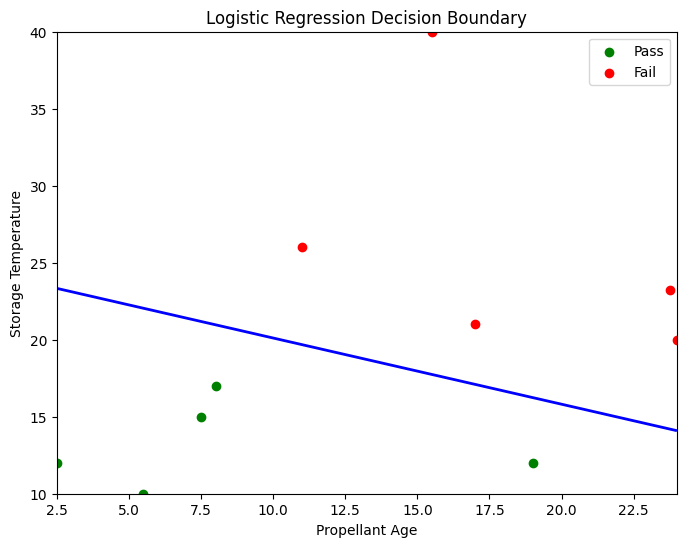

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(propellant_age[pass_fail==1], storage_temp[pass_fail==1], color='green', label='Pass')
plt.scatter(propellant_age[pass_fail==0], storage_temp[pass_fail==0], color='red', label='Fail')

# Plot the decision boundary (contour where P = 0.5)
plt.contour(X, Y, P, levels=[0.5], colors='blue', linewidths=2)

# Add labels and title
plt.xlabel('Propellant Age')
plt.ylabel('Storage Temperature')
plt.title('Logistic Regression Decision Boundary')
plt.legend()
plt.savefig('log_regression_propellants.tif', dpi=1200)
plt.show()